# IVS Weekmonitor Analysis & UN/LOCODE Mapping

This notebook demonstrates how to process the IVS weekmonitor data from Rijkswaterstaat, aggregate cargo by origin-destination (OD) pairs, and map these flows to the inland waterway network using ISRS locodes and Zenodo reference data.

In [1]:
import pathlib
import zipfile
import io
import requests
import pickle
import itertools
import logging
from collections import defaultdict

import pandas as pd
import geopandas as gpd
import shapely.wkt
import shapely.geometry
import networkx as nx
import matplotlib.pyplot as plt
import contextily as cx
import numpy as np
from tqdm.auto import tqdm

# Set up logging
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

/Users/baart_f/src/fis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load IVS Data Directly from Internet
We fetch the latest weekmonitor ZIP and read the CSV content in-memory.

In [2]:
ivs_url = "https://downloads.rijkswaterstaatdata.nl/scheepvaart/goederenvervoer/archief/IVS_weekmonitor_31MAR2026_20260401_051939.zip"

logger.info(f"Fetching IVS data from {ivs_url}...")
r = requests.get(ivs_url, timeout=30)
r.raise_for_status()

with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    csv_filename = z.namelist()[0]
    with z.open(csv_filename) as f:
        ivs_df = pd.read_csv(f, sep=";")

logger.info(f"Loaded {len(ivs_df)} records from {csv_filename}.")
ivs_df.head()

INFO: Fetching IVS data from https://downloads.rijkswaterstaatdata.nl/scheepvaart/goederenvervoer/archief/IVS_weekmonitor_31MAR2026_20260401_051939.zip...


INFO: Loaded 55646 records from IVS_weekmonitor_31MAR2026.csv.


,Jaarmaand,Jaar,Maand,Weeknr,v05_06_Begindt_evenement_iso,v05_06_Begindt_evenement,UNLO_herkomst,UNLO_bestemming,v15_1_Scheepstype_RWS,SK_CODE,v18_Laadvermogen,v28_Beladingscode,v38_Vervoerd_gewicht,v30_4_Containers_TEU_S,nstr_nw,nst2007_nw
0,2602,2026,2,5,2026-02-01T00:00:00+01:00,01 februari 2026 00:00:00 uur,BEANR,DEFRA,2,M8,2660,7,1303000.0,0,3.0,7.2
1,2602,2026,2,5,2026-02-01T00:00:00+01:00,01 februari 2026 00:00:00 uur,BEANR,NLAMS,2,M8,3550,7,1030000.0,0,3.0,8.5
2,2602,2026,2,5,2026-02-01T00:00:00+01:00,01 februari 2026 00:00:00 uur,NLLEY,NLUTC,1,M8,3230,7,514125.0,65,9.0,19.2
3,2602,2026,2,5,2026-02-01T00:00:00+01:00,01 februari 2026 00:00:00 uur,NLAMS,FRSXB,2,M9,3500,7,2122000.0,0,3.0,7.2
4,2602,2026,2,5,2026-02-01T00:00:00+01:00,01 februari 2026 00:00:00 uur,BEGNE,BEANR,2,M10,5220,7,2704000.0,0,8.0,8.2


## 2. Load Network and Define Weights
We load the merged graph and define a custom weight function to discourage routing over sea nodes.

INFO: Loaded network with 7089 nodes.


INFO: Found 323 nodes matching 'NLRTM'


/Users/baart_f/src/fis/.venv/lib/python3.13/site-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 27 is not valid for the current tile provider (valid zooms: 0 - 19).
  warnings.warn(msg)
/var/folders/gr/0j917nfx62x487fv_l35dkn40000gn/T/ipykernel_27684/2869597299.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


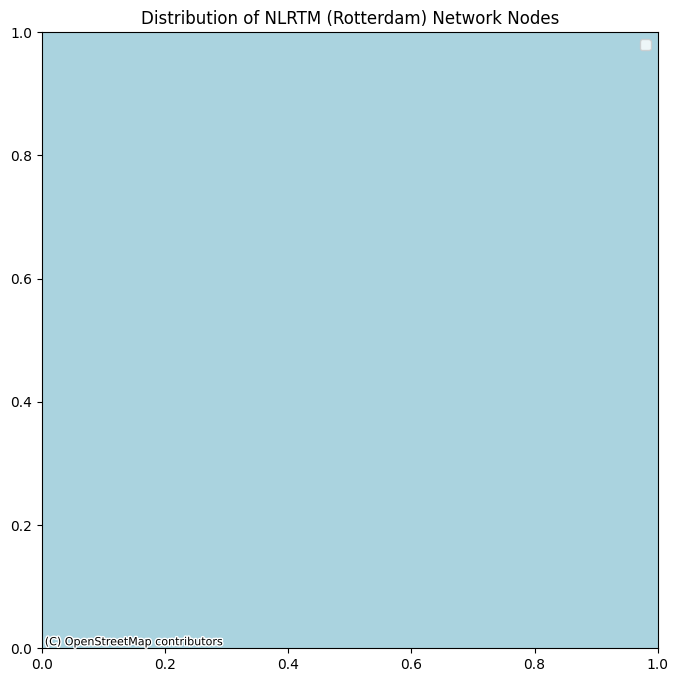

In [3]:
graph_path = pathlib.Path("../output/merged-graph/graph.pickle")
with graph_path.open("rb") as f:
    graph = pickle.load(f)

nodes_gdf = gpd.GeoDataFrame(graph.nodes.values(), index=graph.nodes.keys())
nodes_gdf = nodes_gdf.set_crs(epsg=4326)
logger.info(f"Loaded network with {len(nodes_gdf)} nodes.")


def length_avoid_sea(u, v, d):
    """Custom weight function to penalize sea routes."""
    length = d.get("length_m", 1.0)

    # Identify sea nodes/edges by keywords in Name, ww_name or water_name
    name = (
        str(d.get("name", "")).lower()
        + str(d.get("ww_name", "")).lower()
        + str(d.get("water_name", "")).lower()
    )
    if "zee" in name or "sea" in name:
        return length * 1000000  # Massive penalty

    return length


# Visualize Rotterdam (NLRTM) junction nodes
rtm_nodes = nodes_gdf[nodes_gdf["locode"].str.contains("NLRTM", na=False)]
logger.info(f"Found {len(rtm_nodes)} nodes matching 'NLRTM'")

if not rtm_nodes.empty:
    fig, ax = plt.subplots(figsize=(10, 8))
    rtm_nodes.to_crs(epsg=3857).plot(
        ax=ax, color="red", markersize=10, label="NLRTM Nodes"
    )
    cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)
    ax.set_title("Distribution of NLRTM (Rotterdam) Network Nodes")
    plt.legend()
    plt.show()

## 3. Aggregate OD Data
We group the cargo data by origin (`UNLO_herkomst`) and destination (`UNLO_bestemming`).

In [4]:
# Filter for Dutch origins and destinations (prefix NL)
nl_mask = ivs_df["UNLO_herkomst"].str.startswith("NL", na=False) & ivs_df[
    "UNLO_bestemming"
].str.startswith("NL", na=False)
ivs_nl = ivs_df[nl_mask].copy()

# Aggregate transported weight (v38_Vervoerd_gewicht) by OD pair
od_pairs = (
    ivs_nl.groupby(["UNLO_herkomst", "UNLO_bestemming"])["v38_Vervoerd_gewicht"]
    .sum()
    .reset_index()
)
od_pairs = od_pairs.sort_values(by="v38_Vervoerd_gewicht", ascending=False)

top_100_od = od_pairs.head(100)
top_100_od.head(10)

,UNLO_herkomst,UNLO_bestemming,v38_Vervoerd_gewicht
3711,NLRTM,NLAMS,1.613743e+09
305,NLAMS,NLRTM,5.287459e+08
3840,NLRTM,NLRTM,4.868439e+08
3860,NLRTM,NLVLI,2.207039e+08
4525,NLVLI,NLAMS,2.200845e+08
4567,NLVLI,NLRTM,1.995461e+08
3810,NLRTM,NLMOE,1.896690e+08
226,NLAMS,NLGOU,1.536277e+08
176,NLAMS,NLAMS,1.201441e+08
3852,NLRTM,NLTNZ,1.151215e+08


## 4. Compute Routes and Aggregate Cargo per Fairway Section
We calculate the shortest path for each of the top 100 OD pairs and sum the cargo weight per network edge.

In [5]:
def get_sample_node_for_locode(locode):
    """Find a representative sectionjunction node for the given 5-char UN/LOCODE."""
    mask = nodes_gdf["locode"].str.contains(locode, na=False)
    junction_mask = nodes_gdf["geo_type"] == "sectionjunction"
    matches = nodes_gdf[mask & junction_mask]
    if matches.empty:
        return None
    return matches.index[0]


edge_cargo = defaultdict(float)
edge_info = {}

for idx, row in tqdm(
    top_100_od.iterrows(), total=len(top_100_od), desc="Routing top 100"
):
    u_loc, v_loc, weight = (
        row["UNLO_herkomst"],
        row["UNLO_bestemming"],
        row["v38_Vervoerd_gewicht"],
    )
    u_node, v_node = (
        get_sample_node_for_locode(u_loc),
        get_sample_node_for_locode(v_loc),
    )

    if u_node and v_node:
        try:
            route = nx.shortest_path(graph, u_node, v_node, weight=length_avoid_sea)
            for u, v in itertools.pairwise(route):
                # Handle undirected edges consistently using sorted tuple
                edge_key = tuple(sorted((u, v)))
                edge_cargo[edge_key] += weight
                if edge_key not in edge_info:
                    edge_info[edge_key] = graph.edges[u, v]
        except nx.NetworkXNoPath:
            continue

logger.info(f"Aggregated cargo across {len(edge_cargo)} unique fairway sections.")

# Build GeoDataFrame from aggregated edges
collapsed_data = []
for edge_key, weight in edge_cargo.items():
    data = edge_info[edge_key]
    geom_data = data.get("geometry")
    if isinstance(geom_data, str):
        geom = shapely.wkt.loads(geom_data)
    else:
        geom = geom_data

    if geom:
        collapsed_data.append({"geometry": geom, "cargo_weight": weight})

all_routes_gdf = gpd.GeoDataFrame(collapsed_data, crs="EPSG:4326")

Routing top 100:   0%|                                                                               | 0/100 [00:00<?, ?it/s]

Routing top 100:  33%|██████████████████████▊                                              | 33/100 [00:00<00:00, 321.85it/s]

Routing top 100:  70%|████████████████████████████████████████████████▎                    | 70/100 [00:00<00:00, 348.11it/s]

Routing top 100: 100%|████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 343.88it/s]


INFO: Aggregated cargo across 770 unique fairway sections.


## 5. Visualize Cargo Intensity
Display the total cargo volume per fairway section on a background map.

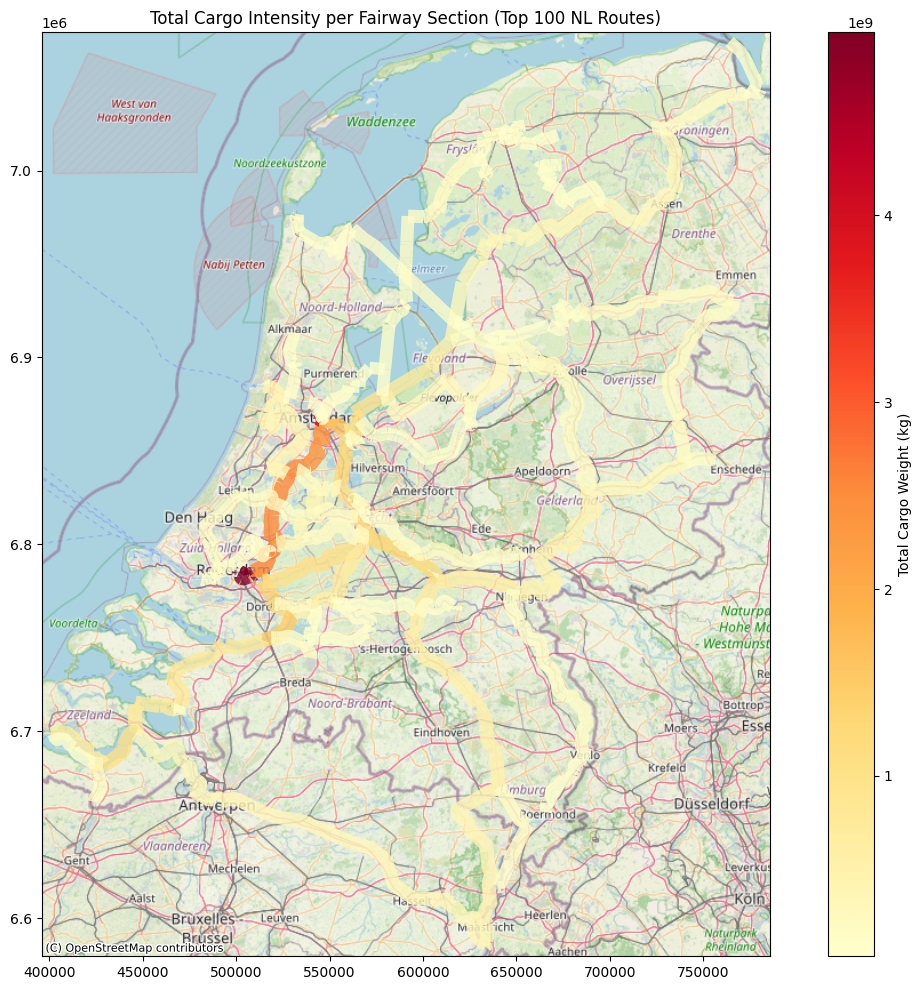

In [6]:
routes_3857 = all_routes_gdf.to_crs(epsg=3857)
fig, ax = plt.subplots(figsize=(15, 12))

# Scale linewidth by cargo weight (log scale)
max_weight = routes_3857["cargo_weight"].max()
routes_3857["linewidth"] = 1 + 10 * (
    np.log1p(routes_3857["cargo_weight"]) / np.log1p(max_weight)
)

routes_3857.plot(
    ax=ax,
    column="cargo_weight",
    cmap="YlOrRd",
    linewidth=routes_3857["linewidth"],
    alpha=0.8,
    legend=True,
    legend_kwds={"label": "Total Cargo Weight (kg)"},
)

minx, miny, maxx, maxy = routes_3857.total_bounds
ax.set_xlim(minx - 5000, maxx + 5000)
ax.set_ylim(miny - 5000, maxy + 5000)
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)
ax.set_title("Total Cargo Intensity per Fairway Section (Top 100 NL Routes)")
plt.show()